In [98]:
import torch
import torch.nn as nn
import train, test
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
from pathlib import Path
import random
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from tqdm.auto import tqdm
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

SE CARGAN LOS CONJUNTOS DE DATOS

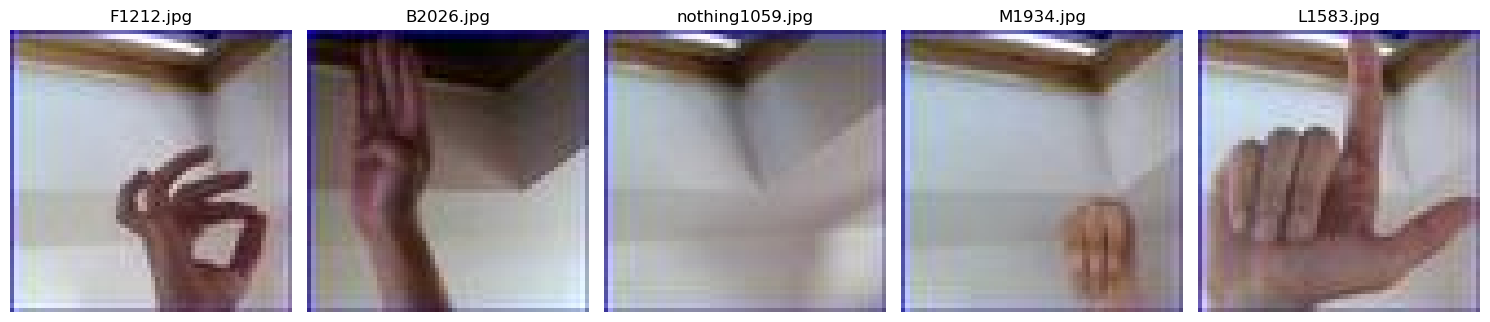

In [33]:
SEMILLA=42
ruta_train = Path("train")
ruta_test = Path("test")

images = list(ruta_train.glob("*.jpg"))
random.seed(SEMILLA)

selected_images = random.sample(images, k=min(5, len(images)))


plt.figure(figsize=(15, 4))
for i, image_path in enumerate(selected_images):
    image = Image.open(image_path)
    plt.subplot(1, len(selected_images), i + 1)
    plt.imshow(image)
    plt.title(image_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

MODELO RED NEURONAL SIMPLE

In [57]:
modelo_mlp = nn.Sequential(

    nn.Flatten(),

    nn.Linear(3 * 64 * 64, 512),
    nn.ReLU(),
    nn.Dropout(0.30),

    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.20),

    nn.Linear(128, 29)
)

MODELO RED NEURONAL CONVOLUCIONAL

In [60]:
modelo_cnn = nn.Sequential(

    # 3x64x64 -> 16x64x64
    nn.Conv2d(
        in_channels=3,
        out_channels=16,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),

    # -> 16x32x32
    nn.MaxPool2d(
        kernel_size=2,
        stride=2
    ),

    # -> 32x32x32
    nn.Conv2d(
        16,
        32,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),

    # -> 32x16x16
    nn.MaxPool2d(2),

    # -> 64x16x16
    nn.Conv2d(
        32,
        64,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),

    # -> 64x8x8
    nn.MaxPool2d(2),

    # 64x8x8 -> 4096
    nn.Flatten(),

    nn.Linear(
        64 * 8 * 8,
        128
    ),
    nn.ReLU(),

    nn.Linear(
        128,
        29
    )
)

MODELO RED NEURONAL MEJORADA

In [61]:
modelo_cnn2 = nn.Sequential(

    # Bloque 1
    nn.Conv2d(
        3,
        32,
        kernel_size=3,
        padding=1
    ),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # Bloque 2
    nn.Conv2d(
        32,
        64,
        kernel_size=3,
        padding=1
    ),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # Bloque 3
    nn.Conv2d(
        64,
        128,
        kernel_size=3,
        padding=1
    ),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # Global Average Pooling
    nn.AdaptiveAvgPool2d((1, 1)),

    # 128x1x1 -> 128
    nn.Flatten(),

    nn.Dropout(0.40),

    nn.Linear(
        128,
        29
    )
)

In [120]:
import re

def obtener_clase(ruta):

    nombre = Path(ruta).stem

    # Eliminar números
    clase = re.sub(r"\d+", "", nombre)

    # Eliminar espacios accidentales
    clase = clase.strip()

    # Normalización
    if len(clase) == 1:
        clase = clase.upper()
    else:
        clase = clase.lower()

    return clase

VERIFICACIÓN DE CLASES

In [122]:
clases_encontradas = [
    obtener_clase(ruta)
    for ruta in imagenes
]

print(sorted(set(clases_encontradas)))

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [123]:
from collections import Counter

conteo = Counter(clases_encontradas)

for clase, cantidad in sorted(conteo.items()):
    print(f"{clase:10s}: {cantidad}")

A         : 600
B         : 600
C         : 600
D         : 600
E         : 600
F         : 600
G         : 600
H         : 600
I         : 600
J         : 600
K         : 600
L         : 600
M         : 600
N         : 600
O         : 600
P         : 600
Q         : 600
R         : 600
S         : 600
T         : 600
U         : 600
V         : 600
W         : 600
X         : 600
Y         : 600
Z         : 600
del       : 600
nothing   : 600
space     : 600


Se ha encontrado que todas las clases tiene la misma cantidad de elementos, i.e. el conjunto está balanceado

In [124]:
CLASES = [
    "A", "B", "C", "D", "E", "F", "G",
    "H", "I", "J", "K", "L", "M", "N",
    "O", "P", "Q", "R", "S", "T", "U",
    "V", "W", "X", "Y", "Z",
    "del", "nothing", "space"
]

encontradas = set(clases_encontradas)
esperadas = set(CLASES)

print("Clases encontradas:")
print(encontradas)

print("\nClases faltantes:")
print(esperadas - encontradas)

print("\nClases inesperadas:")
print(encontradas - esperadas)

Clases encontradas:
{'S', 'P', 'T', 'K', 'L', 'V', 'X', 'G', 'B', 'Z', 'D', 'J', 'N', 'C', 'M', 'space', 'O', 'E', 'R', 'nothing', 'U', 'F', 'H', 'W', 'Y', 'I', 'Q', 'del', 'A'}

Clases faltantes:
set()

Clases inesperadas:
set()


Se tiene que las clases se han cargado correctamente, y no hay faltantes o nuevas en el conjunto

In [163]:
import re

def obtener_clase(ruta):

    nombre = Path(ruta).stem

    # Eliminar números
    clase = re.sub(r"\d+", "", nombre)

    # Eliminar espacios accidentales
    clase = clase.strip()

    # Normalización
    if len(clase) == 1:
        clase = clase.upper()
    else:
        clase = clase.lower()

    return clase

In [137]:
class ASLDataset(Dataset):

    def __init__(self, ruta, transform=None):

        self.ruta = Path(ruta)

        self.imagenes = sorted(
            self.ruta.glob("*.jpg")
        )

        self.transform = transform

        self.clases = [
            "A", "B", "C", "D", "E", "F", "G",
            "H", "I", "J", "K", "L", "M", "N",
            "O", "P", "Q", "R", "S", "T", "U",
            "V", "W", "X", "Y", "Z",
            "del", "nothing", "space"
        ]

        self.clase_a_indice = {
            clase: i
            for i, clase in enumerate(self.clases)
        }

        # Validación inicial
        for ruta_imagen in self.imagenes:

            clase = obtener_clase(ruta_imagen)

            if clase not in self.clase_a_indice:

                raise ValueError(
                    f"Clase inválida '{clase}' "
                    f"en archivo {ruta_imagen.name}"
                )

    def __len__(self):

        return len(self.imagenes)

    def __getitem__(self, idx):

        ruta_imagen = self.imagenes[idx]

        imagen = Image.open(
            ruta_imagen
        ).convert("RGB")

        clase = obtener_clase(ruta_imagen)

        etiqueta = self.clase_a_indice[clase]

        if self.transform:
            imagen = self.transform(imagen)

        return imagen, etiqueta

In [138]:
for i in range(30, 1000):

    ruta = train_dataset.imagenes[i]

    _, etiqueta = train_dataset[i]

    print(
        ruta.name,
        "->",
        etiqueta,
        "->",
        train_dataset.clases[etiqueta]
    )

A1128.jpg -> 0 -> A
A1129.jpg -> 0 -> A
A113.jpg -> 0 -> A
A1130.jpg -> 0 -> A
A1132.jpg -> 0 -> A
A1137.jpg -> 0 -> A
A1139.jpg -> 0 -> A
A1140.jpg -> 0 -> A
A1141.jpg -> 0 -> A
A1145.jpg -> 0 -> A
A1148.jpg -> 0 -> A
A115.jpg -> 0 -> A
A1153.jpg -> 0 -> A
A1154.jpg -> 0 -> A
A1162.jpg -> 0 -> A
A1165.jpg -> 0 -> A
A1167.jpg -> 0 -> A
A1169.jpg -> 0 -> A
A1170.jpg -> 0 -> A
A1171.jpg -> 0 -> A
A1182.jpg -> 0 -> A
A1202.jpg -> 0 -> A
A1211.jpg -> 0 -> A
A122.jpg -> 0 -> A
A1223.jpg -> 0 -> A
A1227.jpg -> 0 -> A
A1228.jpg -> 0 -> A
A123.jpg -> 0 -> A
A1233.jpg -> 0 -> A
A1240.jpg -> 0 -> A
A1242.jpg -> 0 -> A
A1252.jpg -> 0 -> A
A1258.jpg -> 0 -> A
A1263.jpg -> 0 -> A
A1268.jpg -> 0 -> A
A1270.jpg -> 0 -> A
A1271.jpg -> 0 -> A
A1276.jpg -> 0 -> A
A128.jpg -> 0 -> A
A129.jpg -> 0 -> A
A1294.jpg -> 0 -> A
A1295.jpg -> 0 -> A
A1296.jpg -> 0 -> A
A1299.jpg -> 0 -> A
A13.jpg -> 0 -> A
A1301.jpg -> 0 -> A
A1306.jpg -> 0 -> A
A1308.jpg -> 0 -> A
A131.jpg -> 0 -> A
A1319.jpg -> 0 -> A
A1334.jpg

Se observa que las clases se han clasificado correctamente de acuerdo a la letra de ASL

In [139]:
import numpy as np

etiquetas = [
    train_dataset[i][1]
    for i in range(len(train_dataset))
]

valores, cantidades = np.unique(
    etiquetas,
    return_counts=True
)

for valor, cantidad in zip(valores, cantidades):

    print(
        valor,
        train_dataset.clases[valor],
        cantidad
    )

0 A 600
1 B 600
2 C 600
3 D 600
4 E 600
5 F 600
6 G 600
7 H 600
8 I 600
9 J 600
10 K 600
11 L 600
12 M 600
13 N 600
14 O 600
15 P 600
16 Q 600
17 R 600
18 S 600
19 T 600
20 U 600
21 V 600
22 W 600
23 X 600
24 Y 600
25 Z 600
26 del 600
27 nothing 600
28 space 600


Se observa que la cantidad de elementos asignados es la misma para cada clase. Todo el proceso anterior se ha hecho con el fin de que no existan problemas en las entradas de la red neuronal en cuanto a las distintas dimensiones.

In [140]:
transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [141]:
from torchvision import transforms

transform_test = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [142]:
train_dataset = ASLDataset(
    ruta="train",
    transform=transform
)

test_dataset = ASLDataset(
    ruta="test",
    transform=transform_test
)

In [143]:
print("Train:", len(train_dataset))
print("Test:", len(test_dataset))

Train: 17400
Test: 2928


In [144]:
imagen, etiqueta = train_dataset[0]

print(imagen.shape)
print(etiqueta)

torch.Size([3, 64, 64])
0


In [145]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

CONFIGURACIÓN DEL ENTRENAMIENTO

In [146]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Dispositivo:", device)

modelo1 = modelo_mlp.to(device)# modelo red neuronal simple

Dispositivo: cuda


In [147]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Dispositivo:", device)

modelo2 = modelo_cnn.to(device) #modelo cnn 1

Dispositivo: cuda


In [148]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Dispositivo:", device)

modelo3 = modelo_cnn2.to(device) #segundo modelo de cnn

Dispositivo: cuda


ENTRENAMIENTO

In [149]:
epochs = 10
def training(modelo, epochs,train_loader):
    criterio = nn.CrossEntropyLoss()#perdida
    optimizer = torch.optim.Adam(modelo.parameters(),lr=0.001) #optimizador

    train_losses = []
    train_accuracy = []

    for epoch in range(epochs):

        modelo.train()

        perdida_total = 0
        correctos = 0
        total = 0

        for imagenes, etiquetas in train_loader:

            imagenes = imagenes.to(device)
            etiquetas = etiquetas.to(device)

        # -------------------------
        # Reiniciar gradientes
        # -------------------------

            optimizer.zero_grad()

        # -------------------------
        # Forward
        # -------------------------

            salidas = modelo(imagenes)

        # -------------------------
        # Loss
        # -------------------------

            loss = criterio(salidas,etiquetas)

        # -------------------------
        # Backpropagation
        # -------------------------

            loss.backward()

        # -------------------------
        # Actualización
        # -------------------------

            optimizer.step()

            perdida_total += (loss.item()* imagenes.size(0))

            predicciones = salidas.argmax(dim=1)

            correctos += (predicciones == etiquetas).sum().item()

            total += etiquetas.size(0)

        loss_epoch = perdida_total / total

        accuracy_epoch = correctos / total

        train_losses.append(loss_epoch)

        train_accuracy.append(accuracy_epoch)
        print(f"Epoch {epoch+1}/{epochs} | " f"Loss: {loss_epoch:.4f} | "f"Accuracy: {accuracy_epoch:.4f}")
        return train_losses, train_accuracy, accuracy_epoch, loss_epoch

#print(f"Epoch {epoch+1}/{epochs} | " f"Loss: {loss_epoch:.4f} | "f"Accuracy: {accuracy_epoch:.4f}")

In [150]:
train_losses1, train_accuracy1, accuracy_epoch1, loss_epoch1=training(modelo1, epochs, train_loader)

Epoch 1/10 | Loss: 3.3125 | Accuracy: 0.2057


In [151]:
train_losses2, train_accuracy2, accuracy_epoch2, loss_epoch2=training(modelo2, epochs, train_loader)

Epoch 1/10 | Loss: 4.2467 | Accuracy: 0.0657


In [152]:
train_losses3, train_accuracy3, accuracy_epoch3, loss_epoch3=training(modelo3, epochs, train_loader)

Epoch 1/10 | Loss: 3.0574 | Accuracy: 0.1505


PRUEBA DE LOS MODELOS

In [153]:
def prueba(modelo, test_loader):
    modelo.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for imagenes, etiquetas in test_loader:

            imagenes = imagenes.to(device)
            etiquetas = etiquetas.to(device)

            salidas = modelo(imagenes)

            predicciones = salidas.argmax(dim=1)

            y_true.extend(etiquetas.cpu().numpy())

            y_pred.extend(predicciones.cpu().numpy())
        
        return y_true, y_pred

In [154]:
y_true1, y_pred1=prueba(modelo1, test_loader)

In [155]:
y_true2, y_pred2=prueba(modelo2, test_loader)

In [156]:
y_true3, y_pred3=prueba(modelo3, test_loader)

In [157]:
print("Cantidad y_true:", len(y_true1))
print("Cantidad y_pred:", len(y_pred1))

print("\nClases reales:")
print(np.unique(y_true1, return_counts=True))

print("\nClases predichas:")
print(np.unique(y_pred1, return_counts=True))

print("\nClases combinadas:")
print(np.unique(
    np.concatenate([y_true1, y_pred1])
))

print("\nNúmero de clases del dataset:")
print(len(train_dataset.clases))

print(train_dataset.clases)

Cantidad y_true: 2928
Cantidad y_pred: 2928

Clases reales:
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]), array([101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101,
       101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101, 101,
       100, 101, 101]))

Clases predichas:
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]), array([ 41, 111,  81,  92, 115, 100,  79,  45, 134, 198,  70,  95, 122,
       151,  47,  75, 299,  57,  68,  17, 281,  72,   8, 158,  38,  47,
       146, 115,  66]))

Clases combinadas:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28]

Número de clases del dataset:
29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


Se observa que tras el análisis con redes neuronales, las distintas clases no se han visto afectadas en gran medida por el cambio de dimensionalidad y el proceso que cada red lleva a cabo sobre los datos.

In [158]:
def metricas(y_true, y_pred, train_dataset):

    accuracy = accuracy_score(y_true,y_pred)

    print(f"Accuracy Test: {accuracy:.4f}")

    print(classification_report(y_true,y_pred,target_names=train_dataset.clases,zero_division=0))

In [160]:
print("Métricas Modelo RNN simple")
metricas(y_true1,y_pred1, train_dataset)

Métricas Modelo RNN simple
Accuracy Test: 0.4074
              precision    recall  f1-score   support

           A       0.61      0.25      0.35       101
           B       0.47      0.51      0.49       101
           C       0.78      0.62      0.69       101
           D       0.48      0.44      0.46       101
           E       0.39      0.45      0.42       101
           F       0.52      0.51      0.52       101
           G       0.53      0.42      0.47       101
           H       0.78      0.35      0.48       101
           I       0.33      0.44      0.37       101
           J       0.30      0.59      0.40       101
           K       0.67      0.47      0.55       101
           L       0.66      0.62      0.64       101
           M       0.38      0.46      0.41       101
           N       0.36      0.53      0.43       101
           O       0.43      0.20      0.27       101
           P       0.61      0.46      0.52       101
           Q       0.31      0.9

In [161]:
print("Métrica modelo de CNN simple")
metricas(y_true2,y_pred2, train_dataset)

Métrica modelo de CNN simple
Accuracy Test: 0.1093
              precision    recall  f1-score   support

           A       0.12      0.12      0.12       101
           B       0.00      0.00      0.00       101
           C       0.53      0.38      0.44       101
           D       0.42      0.22      0.29       101
           E       0.28      0.21      0.24       101
           F       0.20      0.25      0.22       101
           G       0.12      0.12      0.12       101
           H       0.11      0.76      0.20       101
           I       0.00      0.00      0.00       101
           J       0.03      0.08      0.04       101
           K       0.00      0.00      0.00       101
           L       0.00      0.00      0.00       101
           M       0.00      0.00      0.00       101
           N       0.00      0.00      0.00       101
           O       0.00      0.00      0.00       101
           P       0.00      0.00      0.00       101
           Q       0.00      0

In [162]:
print("Métricas modelo CNN con dropout")
metricas(y_true3,y_pred3, train_dataset)

Métricas modelo CNN con dropout
Accuracy Test: 0.3733
              precision    recall  f1-score   support

           A       0.00      0.00      0.00       101
           B       0.50      0.19      0.27       101
           C       0.86      0.75      0.80       101
           D       0.25      0.32      0.28       101
           E       0.20      0.02      0.04       101
           F       0.18      0.95      0.31       101
           G       0.92      0.24      0.38       101
           H       0.41      0.97      0.58       101
           I       0.26      0.35      0.30       101
           J       0.90      0.27      0.41       101
           K       0.54      0.13      0.21       101
           L       0.71      0.54      0.62       101
           M       0.82      0.09      0.16       101
           N       0.48      0.20      0.28       101
           O       0.91      0.10      0.18       101
           P       0.44      0.56      0.50       101
           Q       0.36    

In [165]:
import seaborn as sns

def matrizc(y_true, y_pred, train_dataset):
    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(16,14))

    sns.heatmap(
        cm,
        cmap="Blues",
        xticklabels=train_dataset.clases,
        yticklabels=train_dataset.clases
    )

    plt.xlabel("Predicción")
    plt.ylabel("Real")

    plt.title(
        "Matriz de confusión - ASL"
    )

    plt.tight_layout()
    plt.show()

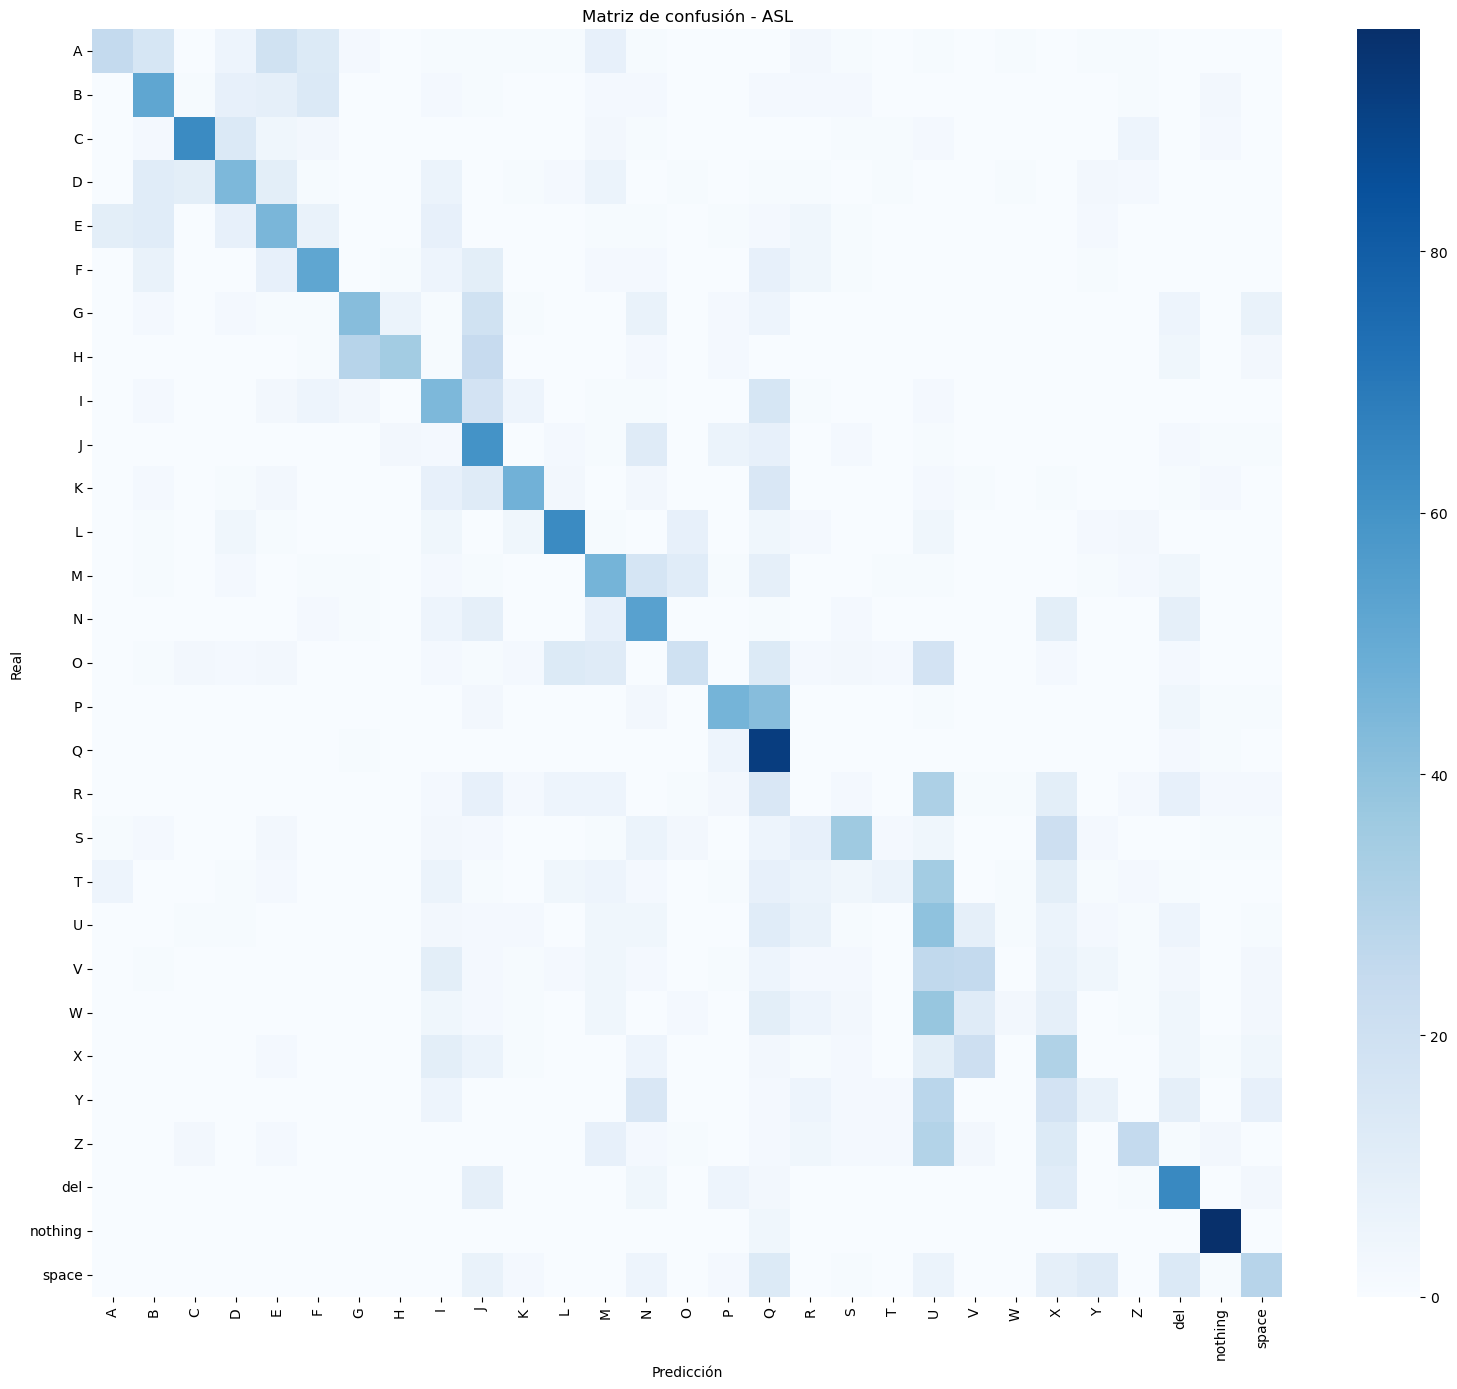

In [166]:
matrizc(y_true1, y_pred1, train_dataset)

Se observa en este caso que la red neuronal simple a llegado a predecir correctamente gran parte de las letras, a excepción de las letras R, T, U, V, W, X, Y, como es posible observar en la diagonal de la matriz de confusión.

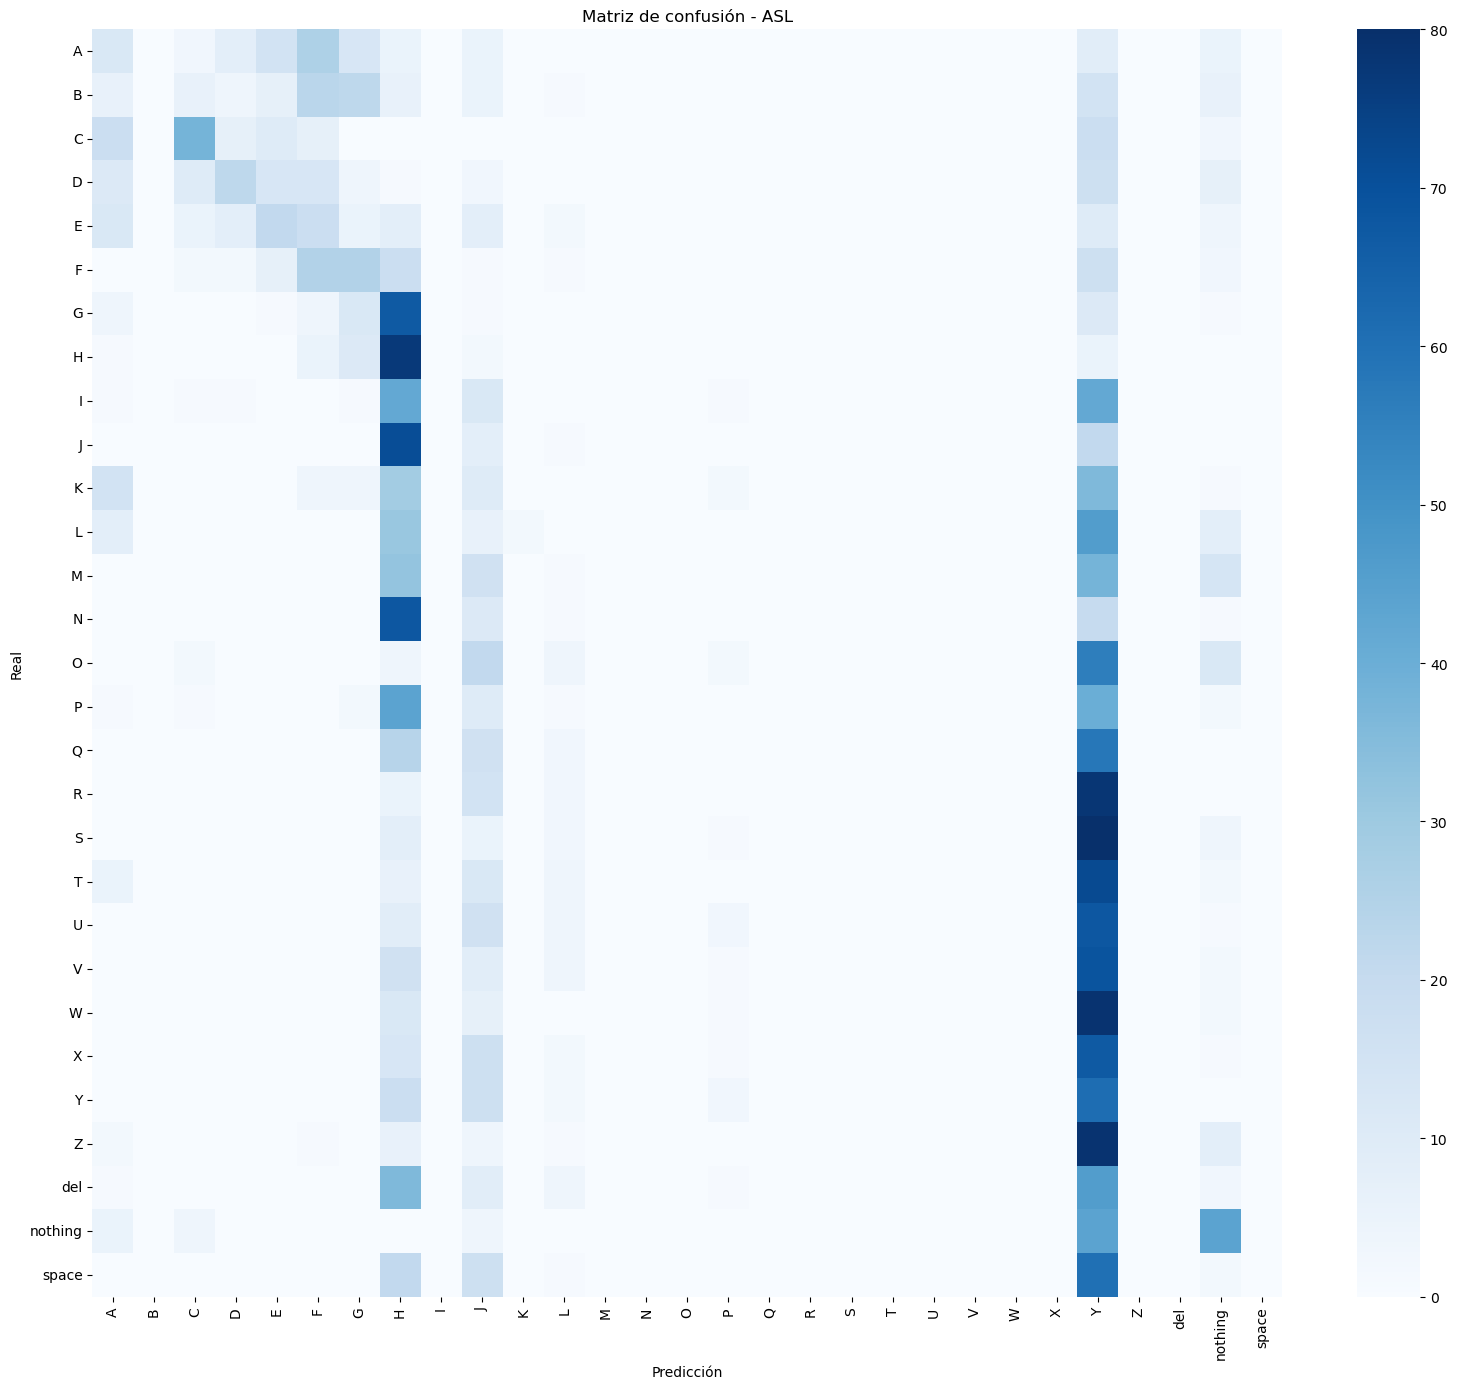

In [167]:
matrizc(y_true2, y_pred2, train_dataset)

Se observa que la red convolucional simple solo ha predicho correctamente C y G, aunque aun en estas se observa cierta nebulosidad alrededor de la diagonal. Puede decirse que este modelo no es bueno para predecir, como también es posible observarlo en las métricas del mismo.

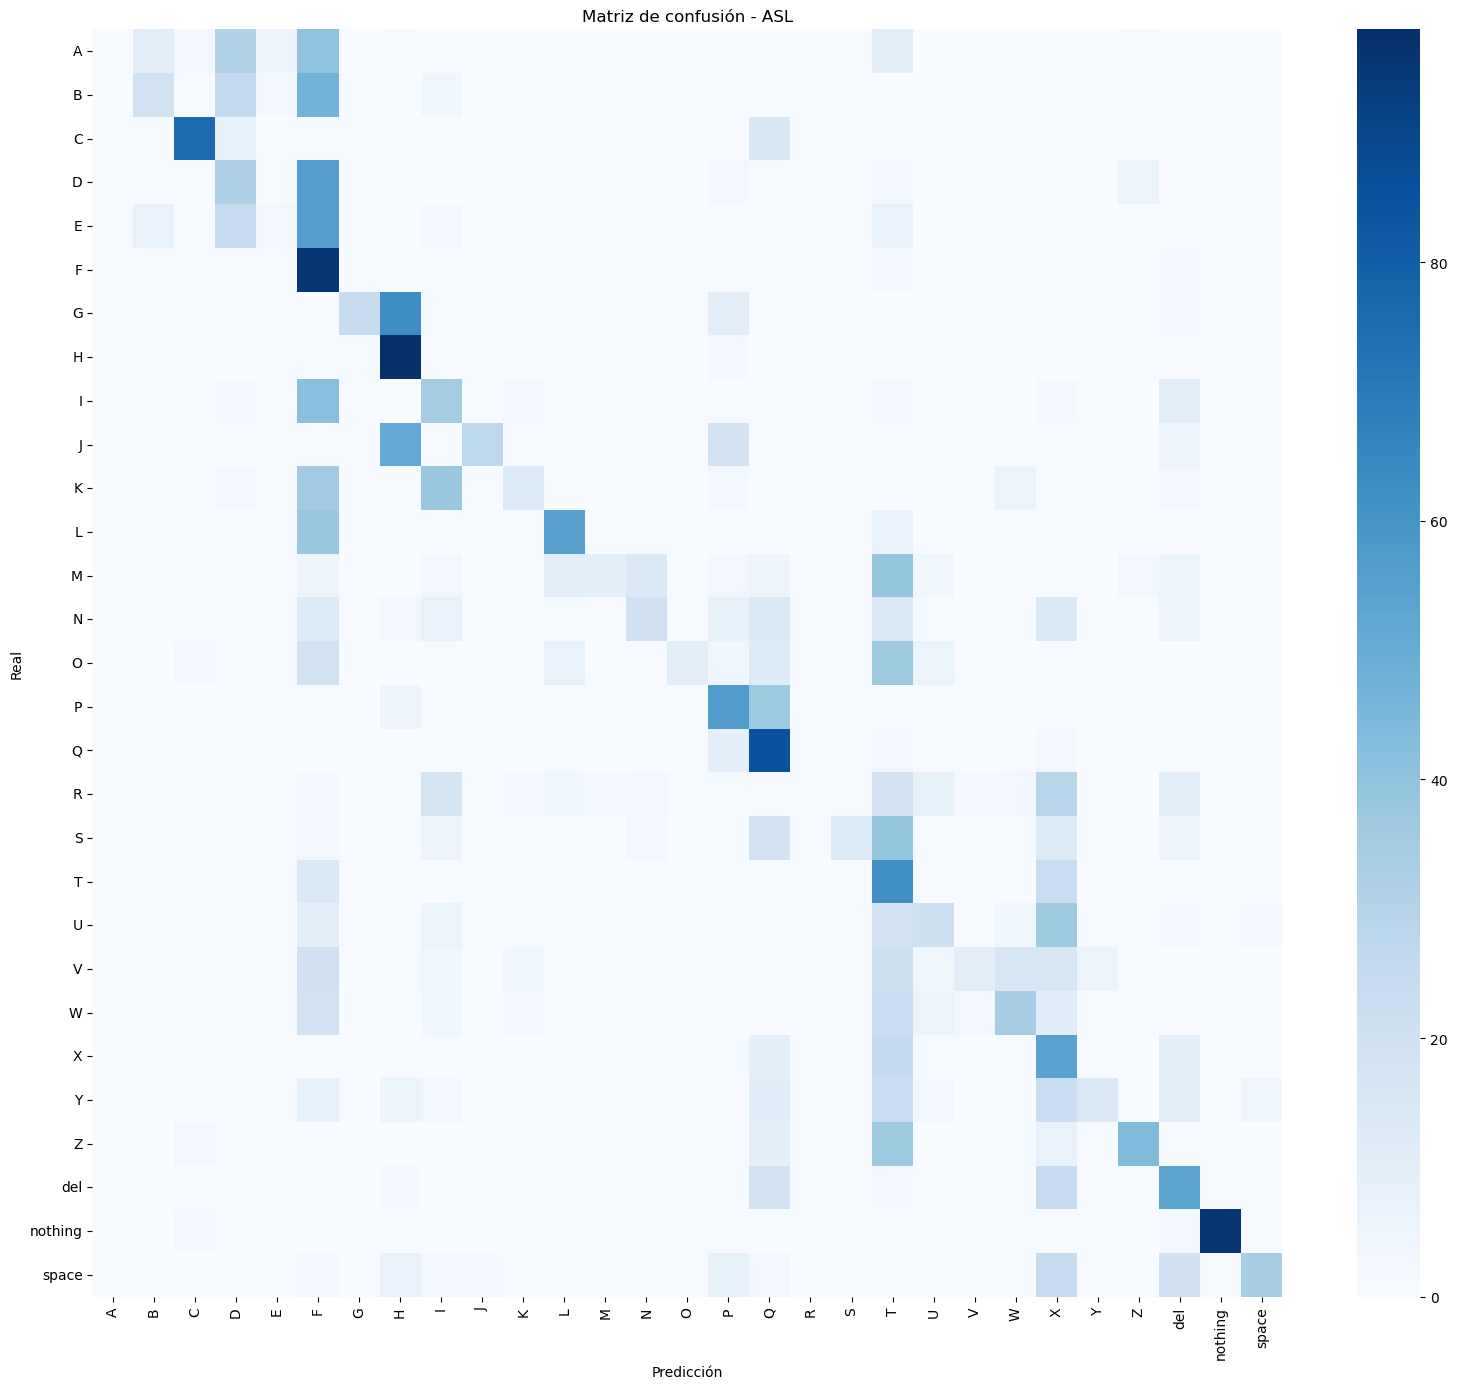

In [168]:
matrizc(y_true3, y_pred3, train_dataset)

Se observa que el modelo de CNN con Dropout es mejor en la predicción respecto al CNN simple. No obstante, presenta mayor variación respecto a la diagonal que la red neuronal simple (con capa lineal) del primer modelo.